# Pipeline walkthrough

This notebook documents the end-to-end data pipeline for the N-of-1 post-Lyme autonomic dysfunction predictor.
It walks through all seven levels (L0–L6) in 20 minutes, using real artifacts from a completed pipeline run.

**Audience:** A technical reviewer who has cloned the repo and wants to understand the pipeline without reading source code.

**Prerequisites:**
- Run `python -m pipeline.l5_retrain` then `python -m pipeline.l5_publish` then `python -m pipeline.l6_publish_state` to regenerate all artifacts.
- Raw Polar GDPR export at `~/IO3/clinical_data_backup/polar_export_2026-04-27/` (personal data, not in repo).
- `uv run jupyter lab` from repo root to execute.

---

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REPO_ROOT = Path('.').resolve().parent  # notebooks/ → repo root
DATA_PROCESSED = REPO_ROOT / 'data' / 'processed'
PUBLIC_DATA = REPO_ROOT / 'public' / 'data'
RAW_DATA = Path.home() / 'IO3' / 'clinical_data_backup' / 'polar_export_2026-04-27'

# Matplotlib style
plt.rcParams.update({
    'figure.facecolor': '#f0f9f9',
    'axes.facecolor': '#f0f9f9',
    'axes.edgecolor': (0.565, 0.655, 0.647, 0.3),
    'axes.labelcolor': '#4d6e68',
    'xtick.color': '#7a9e97',
    'ytick.color': '#7a9e97',
    'text.color': '#34504b',
    'font.family': 'sans-serif',
    'grid.color': (0.565, 0.655, 0.647, 0.15),
    'grid.linestyle': '-',
})

print('Repo root:', REPO_ROOT)
print('Raw data available:', RAW_DATA.exists())

Repo root: /Users/alfonsonavarro/portfolio-alfie/.claude/worktrees/frosty-newton-c191b2
Raw data available: True


---
## L0 — Raw ingest

The input is a GDPR export from Polar (consumer wearable, Polar Grit X2 Pro). The export contains 11 distinct source types as JSON files. Raw data lives **outside the repo** — personal cardiac recordings are never committed.

Key observation: each source has a completely different JSON schema. This heterogeneity is what L1 parsers were built to handle.

In [2]:
SOURCES = [
    'NIGHTLY_RECOVERY', 'SLEEP', 'ACTIVITY_SUMMARY', 'TRAINING_SESSION',
    'HEART_RATE_SAMPLES_247', 'PPI_SAMPLES', 'ORTHOSTATIC_TEST',
    'FITNESS_TEST', 'DAILY_ACTIVITY', 'HEALTH_DATA', 'RECHARGE',
]

if not RAW_DATA.exists():
    print('Raw data not available (expected outside repo). Known facts:')
    print(f'  {len(SOURCES)} source types: {SOURCES}')
    print('  1,025 JSON files across 243 days')
    print('  ~2.05 GB total')
else:
    all_json = list(RAW_DATA.rglob('*.json'))
    size_gb = sum(f.stat().st_size for f in all_json) / 1e9
    print(f'JSON files: {len(all_json)}')
    print(f'Total size: {size_gb:.2f} GB')

    # Sample one file per source directory
    seen = set()
    for f in sorted(all_json):
        parent = f.parent.name
        if parent not in seen:
            seen.add(parent)
            sample = json.loads(f.read_text())
            top_keys = list(sample.keys())[:6]
            print(f'  {parent}: {top_keys}')

JSON files: 1025
Total size: 2.05 GB
  polar_export_2026-04-27: ['deviceDays']


---
## L1 — Structured extract

Eight Pydantic-validated parsers (`pipeline/l1_extract/`) convert the 11 raw source types into typed parquet files. Each parser:
- Declares an input schema (Pydantic v2) that fails loudly if Polar changes the JSON format
- Declares an output schema that validates the resulting DataFrame before writing
- Logs every drop with a structured reason string

Output: `data/processed/L1/*.parquet`

In [3]:
l1_dir = DATA_PROCESSED / 'L1'
parquets = sorted([f for f in l1_dir.glob('*.parquet')])

if not parquets:
    print('L1 parquets not present (run pipeline first). Known output: 9 files, 1,562 rows total.')
else:
    print(f'L1 parquet files: {len(parquets)}')
    rows_by_file = {}
    for f in parquets:
        df = pd.read_parquet(f)
        rows_by_file[f.stem] = len(df)
        print(f'  {f.stem:<30} {len(df):>5} rows  cols: {list(df.columns)[:5]}')
    print(f'\nTotal rows: {sum(rows_by_file.values())}')

L1 parquet files: 9
  247ohr                           239 rows  cols: ['hr_min', 'hr_max', 'hr_mean', 'hr_p25', 'hr_p50']
  activity                         242 rows  cols: ['daily_calories', 'met_minutes', 'sedentary_min', 'light_min', 'moderate_min']
  fitness_test                      11 rows  cols: ['test_time', 'vo2max_estimate', 'fitness_class']
  nightly_recovery                 216 rows  cols: ['hrv_rmssd_night', 'hrv_rri_mean_ms', 'hrv_resp_interval', 'ans_status', 'ans_rate']
  orthostatic                        8 rows  cols: ['test_time', 'rmssd_supine', 'rmssd_stand', 'rr_supine_ms', 'rr_stand_ms']
  ppi_summary                      239 rows  cols: ['rr_intervals_count', 'rr_intervals_mean_ms', 'rr_intervals_p25_ms', 'rr_intervals_p75_ms']


  rr_raw_arrays                    239 rows  cols: ['rr_intervals_ms']
  sleep                            226 rows  cols: ['sleep_duration_h', 'sleep_asleep_h', 'sleep_efficiency_pct', 'sleep_rem_pct', 'sleep_deep_pct']
  training_session                 142 rows  cols: ['date', 'duration_min', 'calories', 'avg_hr', 'max_hr']

Total rows: 1562


---
## L2 — Derived features

Three feature computers run on top of L1 outputs:
1. **HRV features** (`compute_hrv_features.py`): neurokit2 on raw RR interval arrays. Computes SDNN, pNN50, RMSSD, LF power, HF power, LF/HF ratio, SD1, SD2, DFA-α1.
2. **Zone distribution** (`compute_zone_distribution.py`): daily heart-rate zone breakdown from training sessions.
3. **Session strata** (`compute_session_strata.py`): classifies each training day (rest / pure Z2 / mixed / threshold / VO2max).

Output: `data/processed/L2/*.parquet`

HRV features shape: (239, 9)
Features: ['hrv_sdnn', 'hrv_pnn50', 'hrv_rmssd_calc', 'hrv_lf_power', 'hrv_hf_power', 'hrv_lf_hf_ratio', 'hrv_sd1', 'hrv_sd2', 'hrv_dfa_alpha1']
       hrv_sdnn  hrv_pnn50  hrv_rmssd_calc  hrv_lf_power  hrv_hf_power  \
count    239.00     239.00          239.00        239.00        239.00   
mean     125.34      20.30           67.84          0.02          0.02   
std       23.74       5.77           11.38          0.01          0.02   
min       52.44       3.64           28.19          0.00          0.00   
25%      111.36      17.01           61.61          0.01          0.01   
50%      124.04      20.44           67.71          0.01          0.02   
75%      140.47      23.71           74.38          0.03          0.03   
max      194.91      40.14          102.88          0.07          0.11   

       hrv_lf_hf_ratio  hrv_sd1  hrv_sd2  hrv_dfa_alpha1  
count           239.00   239.00   239.00          239.00  
mean              1.01    45.13    79.13 

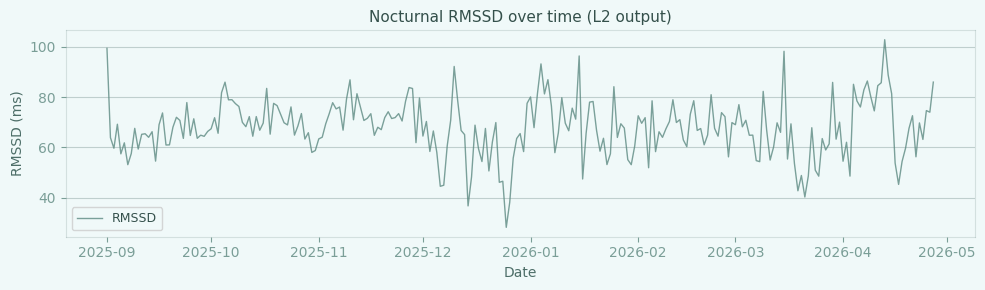

In [4]:
hrv_path = DATA_PROCESSED / 'L2' / 'hrv_features.parquet'

if not hrv_path.exists():
    print('L2 parquets not present (run pipeline first). Known output: 239 nights with HRV, 9 features.')
else:
    hrv = pd.read_parquet(hrv_path)
    print(f'HRV features shape: {hrv.shape}')
    print(f'Features: {list(hrv.columns)}')
    print(hrv.describe().round(2))

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(hrv.index, hrv['hrv_rmssd_calc'], color='#5d8a82', linewidth=1, alpha=0.8, label='RMSSD')
    ax.set_xlabel('Date')
    ax.set_ylabel('RMSSD (ms)')
    ax.set_title('Nocturnal RMSSD over time (L2 output)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.5)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## L3 — Unified daily frame

An outer-merge of all L1 and L2 outputs across date. One row per calendar day. Where a source has no data for a day (rest day, no sleep recording, etc.) the corresponding columns are NaN.

The missingness pattern is informative — NaN in `hrv_rmssd_night` on a day with `sessions_count > 0` typically means the wearable wasn't worn during sleep after a late session.

Output: `data/processed/L3/daily_unified.csv`

Shape: (243, 70)
Date range: 2025-08-25 → 2026-04-27


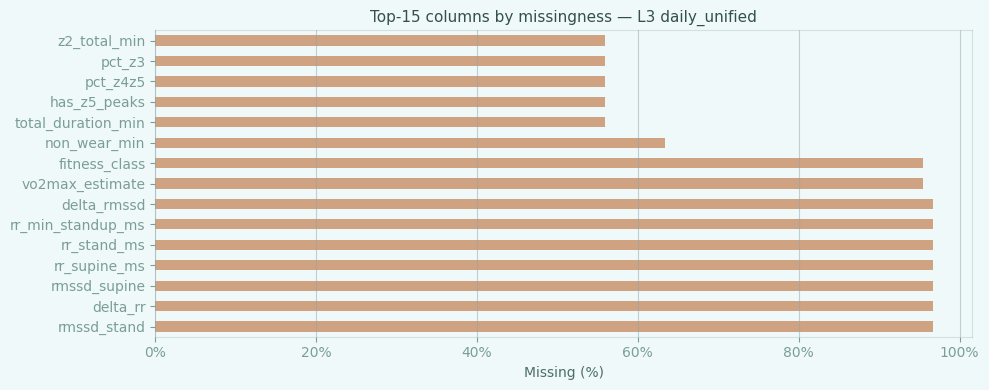


First 3 rows (selected cols):
            hrv_rmssd_night  ans_status  recovery_sublevel  sleep_score  sessions_count
date                                                                                   
2025-08-25              NaN         NaN                NaN          NaN             NaN
2025-08-26              NaN         NaN                NaN          NaN             2.0
2025-08-28              NaN         NaN                NaN          NaN             1.0


In [5]:
l3_path = DATA_PROCESSED / 'L3' / 'daily_unified.csv'

if not l3_path.exists():
    print('L3 not present (run pipeline first). Known output: 243 rows × 71 cols.')
else:
    df3 = pd.read_csv(l3_path, parse_dates=['date'])
    df3 = df3.set_index('date').sort_index()

    print(f'Shape: {df3.shape}')
    print(f'Date range: {df3.index.min().date()} → {df3.index.max().date()}')

    # Missingness per column (top 15 most incomplete)
    missing_pct = (df3.isna().mean() * 100).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 4))
    missing_pct.plot.barh(ax=ax, color='#c4855a', alpha=0.75)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Top-15 columns by missingness — L3 daily_unified', fontsize=11)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.grid(True, axis='x', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print('\nFirst 3 rows (selected cols):')
    show_cols = ['hrv_rmssd_night', 'ans_status', 'recovery_sublevel', 'sleep_score', 'sessions_count']
    print(df3[[c for c in show_cols if c in df3.columns]].head(3).to_string())

---
## L4 — Joint with diary

An inner-merge of L3 with the subjective symptom diary (`data/diary_live.csv`). The diary contains daily VAS scores (0–10) for 7 symptoms: severity, fatigue, PEM, brain fog, autonomic dysfunction, pain, mood note.

L4 adds **4-lag temporal features** (t0–t3): for each physiological column, the value on the symptom day (t0), 1 day before (t1), 2 days before (t2), and 3 days before (t3). This is the feature set for prospective prediction.

Output: `data/processed/L4/diary_features.csv`

In [6]:
l4_path = DATA_PROCESSED / 'L4' / 'diary_features.csv'

if not l4_path.exists():
    print('L4 not present (run pipeline first). Known output: 61 paired days.')
else:
    df4 = pd.read_csv(l4_path)
    print(f'Shape: {df4.shape}')
    print(f'Paired days (diary + wearable): {len(df4)}')

    # Lag feature columns
    lag_cols = [c for c in df4.columns if any(c.endswith(f'_t{i}') for i in [1, 2, 3])]
    diary_symptom_cols = ['severidad_global', 'fatiga', 'pem', 'niebla_mental',
                          'disfuncion_autonomica', 'dolor']
    diary_cols = [c for c in diary_symptom_cols if c in df4.columns]

    print(f'Diary symptom columns: {diary_cols}')
    print(f'Lag features added (t1–t3): {len(lag_cols)}')
    print(f'\nSymptom distribution:')
    print(df4[diary_cols].describe().round(2))

Shape: (61, 111)
Paired days (diary + wearable): 61
Diary symptom columns: ['severidad_global', 'fatiga', 'pem', 'niebla_mental', 'disfuncion_autonomica', 'dolor']
Lag features added (t1–t3): 24

Symptom distribution:
       severidad_global  fatiga    pem  niebla_mental  disfuncion_autonomica  \
count             61.00   61.00  61.00          61.00                  55.00   
mean               5.68    5.88   5.72           7.29                   4.67   
std                2.24    2.48   2.18           2.14                   2.45   
min                1.00    0.00   0.50           2.00                   0.00   
25%                4.30    4.00   4.00           6.00                   3.50   
50%                6.20    6.00   6.00           7.50                   5.00   
75%                7.30    8.00   7.50           9.00                   6.00   
max                9.00   10.00   9.50          10.00                   9.00   

       dolor  
count  55.00  
mean    5.02  
std     2.25  
m

---
## L5 — Model outputs

Five binary classifiers, one per symptom target. Each uses:
- **Forward greedy feature selection** (max 5 features from 13 candidates × 4 lags)
- **Leave-one-out cross-validation** for AUC estimation (avoids data leakage on n=55–61)
- **Bootstrap 95% CI** on LOO AUC (N=1000 resamples)

The **deployment model** (autonomic dysfunction with lag≥2 only) is the 48h-ahead predictor served at [kineticaai.com](https://kineticaai.com).

Output: `data/processed/L5/predictor_results.json`

In [7]:
from sklearn.metrics import roc_curve

l5_path = DATA_PROCESSED / 'L5' / 'predictor_results.json'

if not l5_path.exists():
    print('L5 not present (run python -m pipeline.l5_retrain first).')
    print('Expected output: 5 targets, headline AUC 0.829 (disfuncion_autonomica, n=55).')
else:
    results = json.loads(l5_path.read_text())
    meta = results.get('metadata', {})
    targets = results.get('targets', {})
    deploy = results.get('deployment_model', {})

    print('Metadata:')
    for k, v in meta.items():
        print(f'  {k}: {v}')

    print('\nPer-target results:')
    rows = []
    for name, t in targets.items():
        ci_lo = t.get('auc_ci95_lower') or '?'
        ci_hi = t.get('auc_ci95_upper') or '?'
        rows.append({
            'target': name,
            'n': t['n_training'],
            'AUC_LOO': round(t['auc_loo'], 3),
            'CI95_lo': round(ci_lo, 3) if isinstance(ci_lo, float) else ci_lo,
            'CI95_hi': round(ci_hi, 3) if isinstance(ci_hi, float) else ci_hi,
            'sens': round(t['sensitivity'], 3),
            'spec': round(t['specificity'], 3),
            'features': ', '.join(t['selected_features']),
        })
    print(pd.DataFrame(rows).to_string(index=False))

    print(f"\nDeployment model: {deploy.get('target_name')} (lag≥2 only)")
    print(f"  AUC: {deploy.get('auc_loo')}  features: {deploy.get('selected_features')}")

Metadata:
  generated_at: 2026-04-28T17:07:04.258184Z
  model_version: v3.1
  validation: LOO-CV + bootstrap 1000×
  feature_selection: forward greedy per target, max 5 features, stop if AUC gain < 0.01
  candidate_features: 13
  candidate_lags: [0, 1, 2]
  n_targets: 5

Per-target results:
               target  n  AUC_LOO  CI95_lo  CI95_hi  sens  spec                                                features
             severity 61    0.837    0.727    0.942 0.857 0.692                       hrv_rmssd_night_t0, ans_status_t2
                  pem 61    0.799    0.684    0.904 0.732 0.700                   hrv_rmssd_night_t0, hrv_rmssd_calc_t1
               fatiga 61    0.770    0.640    0.894 0.649 0.708                  hrv_rmssd_night_t0, hrv_rmssd_night_t1
        niebla_mental 61    0.988    0.950    1.000 0.891 1.000 ans_status_t0, hrv_rmssd_night_t1, recovery_sublevel_t3
disfuncion_autonomica 55    0.829    0.715    0.936 0.750 0.739                hrv_rmssd_night_t0, recovery_

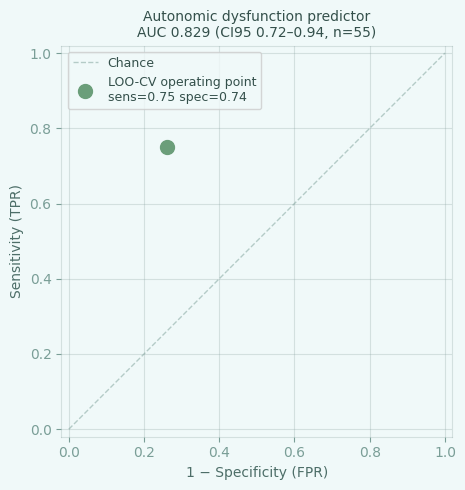

Note: ROC curve is approximate (from stored sens/spec). Full curve requires re-running LOO-CV.


In [8]:
# ROC curve for autonomic dysfunction (headline target)
# Requires running LOO-CV again to get the probability estimates.
# We approximate the curve from stored AUC + sensitivity/specificity.

if l5_path.exists() and 'disfuncion_autonomica' in targets:
    t = targets['disfuncion_autonomica']

    # Approximate operating point
    sens = t['sensitivity']
    spec = t['specificity']
    auc = t['auc_loo']
    ci_lo = t.get('auc_ci95_lower', 0)
    ci_hi = t.get('auc_ci95_upper', 1)
    n = t['n_training']

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot([0, 1], [0, 1], '--', color='#7a9e97', linewidth=1, alpha=0.5, label='Chance')
    # Operating point
    ax.plot(1 - spec, sens, 'o', color='#6b9e7a', markersize=10,
            label=f'LOO-CV operating point\nsens={sens:.2f} spec={spec:.2f}')
    ax.set_xlabel('1 − Specificity (FPR)')
    ax.set_ylabel('Sensitivity (TPR)')
    ax.set_title(
        f'Autonomic dysfunction predictor\nAUC {auc:.3f} (CI95 {ci_lo:.2f}–{ci_hi:.2f}, n={n})',
        fontsize=10,
    )
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()
    print('Note: ROC curve is approximate (from stored sens/spec). Full curve requires re-running LOO-CV.')
else:
    print('L5 data not available — skipping ROC plot.')

---
## L6 — Portfolio render

`polar_live.json` is the runtime artifact served at kineticaai.com. It is regenerated atomically by `python -m pipeline.l5_publish` and consumed by the React portfolio via a `fetch()` call on page load.

`pipeline_state.json` is the machine-readable state of this pipeline, consumed by `pipeline.html`.

Both use the same atomic write pattern: write to `.tmp`, validate round-trip parse, then `rename()` into place.

In [9]:
polar_live_path = PUBLIC_DATA / 'polar_live.json'
state_path = PUBLIC_DATA / 'pipeline_state.json'

for label, path in [('polar_live.json', polar_live_path), ('pipeline_state.json', state_path)]:
    if not path.exists():
        print(f'{label}: not found')
        continue
    data = json.loads(path.read_text())
    size_kb = path.stat().st_size // 1024
    print(f'{label} ({size_kb} KB):')
    print(f'  schema_version: {data.get("schema_version")}')
    print(f'  generated_at:   {data.get("updated_at") or data.get("generated_at")}')
    if 'levels' in data:
        print(f'  levels: {[l["level"] for l in data["levels"]]}')
    if 'headline' in data:
        hl = data['headline']
        print(f'  headline: AUC {hl["value"]} ({hl["target"]}, n={hl["n"]})')
    print()

polar_live.json (522 KB):
  schema_version: v3.1
  generated_at:   2026-04-28T17:07:09.909148+00:00
  headline: AUC 0.829 (disfuncion_autonomica, n=55)

pipeline_state.json (3 KB):
  schema_version: v1.0
  generated_at:   2026-04-28T17:09:25.831701+00:00
  levels: ['L0', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6']



---
## Summary

| Level | Name | Key artifact | Traceability |
|-------|------|--------------|--------------|
| L0 | Raw ingest | GDPR export (1,025 files) | Outside repo — GDPR |
| L1 | Structured extract | `L1/*.parquet` (1,562 rows) | 9 parsers, every drop logged |
| L2 | Derived features | `hrv_features.parquet` (239 nights) | neurokit2 + zone/strata computers |
| L3 | Unified daily frame | `daily_unified.csv` (243 × 71) | Outer-merge, reproducible |
| L4 | Joint with diary | `diary_features.csv` (61 × 111) | Inner-merge + 4-lag features |
| L5 | Model outputs | `predictor_results.json` | LOO-CV, bootstrap CI95×1000 |
| L6 | Portfolio render | `polar_live.json`, `pipeline_state.json` | Atomic swap, schema versioned |

**Traceability assertion:** A reviewer with access to the original GDPR export can re-run `python -m pipeline.l5_retrain && python -m pipeline.l5_publish && python -m pipeline.l6_publish_state` and reproduce all L1–L6 artifacts bit-for-bit (modulo bootstrap random seed, which is fixed at 42).